# 📰 News Headline Sentiment Dashboard
### Real-Time NLP Project — Full Pipeline

---

## 🗺️ What You Will Build
A live dashboard that:
1. Fetches real-time news headlines from **NewsAPI** (free tier)
2. Cleans and processes text using **Regex**
3. Applies **Classical NLP** (tokenization, stopword removal, frequency analysis)
4. Runs **Sentiment Analysis** using VADER and TextBlob
5. Scrapes additional article text using **BeautifulSoup + Requests**
6. Visualizes everything in an interactive **Sentiment Dashboard**

## 📚 Concepts Covered
| Concept | Where Used |
|---|---|
| Basic NLP (tokenization, stopwords, frequency) | Section 4 |
| Sentiment Analysis with Classical NLP (VADER, TextBlob) | Section 5 |
| Regex for Text Processing | Section 3 |
| Calling REST APIs & Handling JSON | Section 2 |
| Web Scraping with BeautifulSoup/Requests | Section 6 |
| Collecting & Analyzing Web Data for NLP | Section 7 |

## 🔑 API Setup
- **NewsAPI**: Free tier at https://newsapi.org/register  
  → Gives you **100 requests/day**, access to 70,000+ sources  
  → After registering, copy your API key below

---

## ⚙️ Section 0 — Install & Import Dependencies

Run this cell first. It installs all required packages.

In [18]:
# ── Download NLTK data packages ────────────────────────────────────────────
# One-time downloads saved to ~/nltk_data.
# Re-running is safe — quiet=True suppresses 'already downloaded' messages.
import nltk
nltk.download('punkt',           quiet=True)  # Tokenizer: splits text into words
nltk.download('stopwords',        quiet=True)  # Common filler words (the, is, at...)
nltk.download('averaged_perceptron_tagger', quiet=True)  # Part-of-speech tagger
nltk.download('punkt_tab',        quiet=True)  # Updated tokenizer tables
nltk.download('averaged_perceptron_tagger_eng')           # English POS model

print('All NLTK data ready!')

All NLTK data ready!


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\John\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [19]:
# ── Core libraries ──────────────────────────────────────────────
import requests
import json
import re
import time
from datetime import datetime

# ── Data handling ────────────────────────────────────────────────
import pandas as pd

# ── NLP ──────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist

# Sentiment Analysis
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ── Web Scraping ─────────────────────────────────────────────────
from bs4 import BeautifulSoup

# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


---
## 🔑 Section 1 — Configuration

**Action required:** Paste your NewsAPI key below.  
Get a free key at → https://newsapi.org/register (takes 30 seconds)

We also define the **news categories** and **search queries** you want to track.

In [20]:
NEWS_API_KEY = "30aad817f95c495aab1ba83539cc84c5"
CATEGORIES = ["technology", "business"]
SEARCH_QUERIES = ["economy", "artificial intelligence"]
PAGE_SIZE = 1
COUNTRY ="us" 
BASE_URL = "https://newsapi.org/v2"

In [21]:
# Collector list — accumulates ALL article dicts across every category and keyword.
# Each article is tagged with 'query_category' before appending so we know its origin.
# The production fetch functions (Section 2) will populate this list.
all_articles = []


---
## 🌐 Section 2 — Calling the NewsAPI REST API & Handling JSON

### Concept: REST APIs
A REST API is a web service you communicate with via HTTP requests.  
- **Endpoint**: a URL that represents a resource (e.g. `/v2/top-headlines`)
- **Query parameters**: filters passed in the URL (e.g. `?category=technology&pageSize=20`)
- **Response**: JSON — a structured text format Python can parse into dicts/lists

### NewsAPI Endpoints Used
| Endpoint | Purpose |
|---|---|
| `/v2/top-headlines` | Live breaking news by category/country |
| `/v2/everything` | Search across all articles by keyword |

In [22]:
def fetch_top_headlines(category: str, country: str = COUNTRY, page_size: int = PAGE_SIZE) -> list:
    """
    Fetch top headlines for a given category from NewsAPI.
    Returns a list of article dicts.
    """
    url = f"{BASE_URL}/top-headlines"
    params = {
        "apiKey": NEWS_API_KEY,
        "category": category,
        "country": country,
        "pageSize": page_size
    }

    response = requests.get(url, params=params, timeout=10)

    # Always check the status code before using the response
    if response.status_code != 200:
        print(f"  ⚠️  API error {response.status_code}: {response.json().get('message', 'unknown')}")
        return []

    data = response.json()          # parse JSON → Python dict
    articles = data.get("articles", [])
    print(f"  ✅ [{category:15s}] fetched {len(articles):3d} articles  (status: {data['status']})")
    return articles


def fetch_by_keyword(query: str, page_size: int = PAGE_SIZE) -> list:
    """
    Search all articles matching a keyword using /v2/everything endpoint.
    """
    url = f"{BASE_URL}/everything"
    params = {
        "apiKey": NEWS_API_KEY,
        "q": query,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": page_size
    }

    response = requests.get(url, params=params, timeout=10)

    if response.status_code != 200:
        print(f"  ⚠️  [{query}] API error {response.status_code}")
        return []

    articles = response.json().get("articles", [])
    print(f"  🔍 ['{query}'] → {len(articles)} articles found")
    return articles


# ── Fetch all data ───────────────────────────────────────────────
print("Fetching top headlines by category...")
all_articles = []

for cat in CATEGORIES:
    articles = fetch_top_headlines(cat)
    for art in articles:
        art["query_category"] = cat   # tag each article with its category
    all_articles.extend(articles)
    time.sleep(0.3)                   # be polite to the API

print(f"\nFetching articles by keyword...")
for query in SEARCH_QUERIES:
    articles = fetch_by_keyword(query)
    for art in articles:
        art["query_category"] = f"kw:{query}"
    all_articles.extend(articles)
    time.sleep(0.3)

print(f"\n📦 Total articles collected: {len(all_articles)}")

Fetching top headlines by category...
  ✅ [technology     ] fetched   1 articles  (status: ok)
  ✅ [business       ] fetched   1 articles  (status: ok)

Fetching articles by keyword...
  🔍 ['economy'] → 1 articles found
  🔍 ['artificial intelligence'] → 1 articles found

📦 Total articles collected: 4


In [23]:
all_articles[0]["content"]  # peek at the first article's structure

'After boosting AI Pro storage earlier this month, Google One is now running a limited-time YouTube Premium discount.\r\nThis offer is available for Google One Premium subscribers paying $9.99 per month… [+948 chars]'

In [24]:
# ── Inspect the raw JSON structure of one article ────────────────
print("📄 Raw JSON structure of a single article:")
print(json.dumps(all_articles[0], indent=2))

📄 Raw JSON structure of a single article:
{
  "source": {
    "id": null,
    "name": "9to5google.com"
  },
  "author": "Abner Li",
  "title": "Google One discount takes 50% off YouTube Premium for a year - 9to5Google",
  "description": "After boosting AI Pro storage earlier this month, Google One is now running a limited-time YouTube Premium discount. This offer...",
  "url": "http://9to5google.com/2026/04/15/google-one-youtube-premium/",
  "urlToImage": "https://i0.wp.com/9to5google.com/wp-content/uploads/sites/4/2026/01/Google-One-app-storage-2.jpg?resize=1200%2C628&quality=82&strip=all&ssl=1",
  "publishedAt": "2026-04-15T23:19:00Z",
  "content": "After boosting AI Pro storage earlier this month, Google One is now running a limited-time YouTube Premium discount.\r\nThis offer is available for Google One Premium subscribers paying $9.99 per month\u2026 [+948 chars]",
  "query_category": "technology"
}


In [25]:
# ── Convert to a clean Pandas DataFrame ─────────────────────────
def articles_to_dataframe(articles: list) -> pd.DataFrame:
    rows = []
    for art in articles:
        rows.append({
            "title":       art.get("title") or "",
            "description": art.get("description") or "",
            "source":      art.get("source", {}).get("name") or "Unknown",
            "url":         art.get("url") or "",
            "published_at":art.get("publishedAt") or "",
            "category":    art.get("query_category") or "general",
            "full_text":   " ".join(filter(None, [
                art.get("title") or "",
                art.get("description") or "",
                art.get("content") or ""
            ]))
        })

    df = pd.DataFrame(rows)
    # Parse dates
    df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
    # Drop duplicates
    df = df.drop_duplicates(subset="title")
    df = df[df["title"].str.strip() != ""]
    df = df.reset_index(drop=True)
    return df

df = articles_to_dataframe(all_articles)
print(f"DataFrame shape: {df.shape}")
df.head(3)

DataFrame shape: (4, 7)


,title,description,source,url,published_at,category,full_text
0,Google One discount takes 50% off YouTube Prem...,After boosting AI Pro storage earlier this mon...,9to5google.com,http://9to5google.com/2026/04/15/google-one-yo...,2026-04-15 23:19:00+00:00,technology,Google One discount takes 50% off YouTube Prem...
1,"Amid wellness craze, FDA weighs lifting peptid...",Health Secretary Robert F. Kennedy Jr. is a se...,The Washington Post,https://www.washingtonpost.com/health/2026/04/...,2026-04-16 00:38:56+00:00,business,"Amid wellness craze, FDA weighs lifting peptid..."
2,Indian officials see Iran war oil shock as dis...,India is drawing on its Covid-era playbook to ...,The Times of India,https://economictimes.indiatimes.com/industry/...,2026-04-16 02:42:11+00:00,kw:economy,Indian officials see Iran war oil shock as dis...


---
## 🔧 Section 3 — Regex for Text Processing

### Concept: Regular Expressions
Regex is a pattern-matching language built into Python's `re` module.  
It's essential for NLP pre-processing — removing noise, extracting structured info.

| Pattern | Meaning |
|---|---|
| `[^a-zA-Z\s]` | Match anything that is NOT a letter or space |
| `\b[A-Z]{2,}\b` | Match ALL-CAPS words (often tickers, abbreviations) |
| `\d{4}` | Match 4-digit numbers (years) |
| `https?://\S+` | Match URLs |
| `\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+` | Match proper names (Named Entity heuristic) |

In [26]:
# ── Text cleaning utilities (defined ONCE here, used throughout) ──────────
# PATTERNS is a dict of compiled regexes — compiled once for performance.
# clean_text(), extract_proper_nouns(), extract_tickers() are defined below.
# All subsequent sections use these functions directly.
# ── Regex patterns used in this project ─────────────────────────
PATTERNS = {
    "url":         re.compile(r'https?://\S+'),
    #before → "Read more at https://bbc.com/news/article-123 today"
    #after  → "Read more at   today"
    "html_tag":    re.compile(r'<[^>]+>'),
    #before → "<b>BREAKING:</b> Markets <em>fall</em> sharply"
    #after  → " BREAKING:  Markets  fall  sharply"
    "punctuation": re.compile(r'[^a-zA-Z\s]'),
    #before → "Apple stock up 3.4% — best day since 2021!"
    #after  → "Apple stock up      best day since      "
    "extra_space": re.compile(r'\s+'),
    #before → "Apple   stock    up      best   day"
    #after  → "Apple stock up best day"
    "ticker":      re.compile(r'\b[A-Z]{2,5}\b'),          # stock tickers / abbreviations
    #input   → "AAPL and TSLA both rose as NASA announced funding"
    #extracts → ["AAPL", "TSLA", "NASA"]
    "proper_noun": re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),  # naive NER
    #input    → "Elon Musk met Tim Cook in New York yesterday"
    #extracts → ["Elon Musk", "Tim Cook", "New York"]
    "year":        re.compile(r'\b(19|20)\d{2}\b'),
    #input    → "The 2024 budget follows the 2023 deficit report"
    #extracts → ["2024", "2023"]
    "number":      re.compile(r'\b\d+\.?\d*\b'),
    #input    → "Stocks fell 4.2 points and GDP grew by 1 percent"
    #extracts → ["4.2", "1"]
    "chars_bracket": re.compile(r'\[\+?\d+\s*chars?\]'),   # NewsAPI truncation marker
    #before → "The economy shrank [+247 chars]"
    #after  → "The economy shrank  "
}


def clean_text(text: str) -> str:
    """Full regex cleaning pipeline for NLP."""
    text = PATTERNS["html_tag"].sub(' ', text)        # remove HTML tags
    text = PATTERNS["url"].sub(' ', text)             # remove URLs
    text = PATTERNS["chars_bracket"].sub(' ', text)   # remove [+N chars] artifacts
    text = PATTERNS["punctuation"].sub(' ', text)     # remove punctuation/numbers
    text = PATTERNS["extra_space"].sub(' ', text)     # normalize whitespace
    return text.strip().lower()


def extract_proper_nouns(text: str) -> list:
    """Extract likely named entities using a regex heuristic."""
    return PATTERNS["proper_noun"].findall(text)


def extract_tickers(text: str) -> list:
    """Extract stock ticker / acronym candidates."""
    return PATTERNS["ticker"].findall(text)


# ── Apply cleaning to the DataFrame ─────────────────────────────
df["clean_text"]    = df["full_text"].apply(clean_text)
df["proper_nouns"]  = df["full_text"].apply(extract_proper_nouns)
df["tickers"]       = df["title"].apply(extract_tickers)

# ── Demo: show before vs after cleaning ─────────────────────────
idx = 0
print("ORIGINAL:\n", df['full_text'].iloc[idx][:300])
print("\nCLEANED:\n",  df['clean_text'].iloc[idx][:300])
print("\nPROPER NOUNS FOUND:", df['proper_nouns'].iloc[idx][:5])

ORIGINAL:
 Google One discount takes 50% off YouTube Premium for a year - 9to5Google After boosting AI Pro storage earlier this month, Google One is now running a limited-time YouTube Premium discount. This offer... After boosting AI Pro storage earlier this month, Google One is now running a limited-time YouT

CLEANED:
 google one discount takes off youtube premium for a year to google after boosting ai pro storage earlier this month google one is now running a limited time youtube premium discount this offer after boosting ai pro storage earlier this month google one is now running a limited time youtube premium d

PROPER NOUNS FOUND: ['Google One', 'Google One', 'Google One', 'Google One Premium']


---
## 🧠 Section 4 — Basic NLP: Tokenization, Stopwords & Frequency Analysis

### Concepts Covered
- **Tokenization** — splitting text into individual words (tokens)
- **Stopword removal** — filtering out common words (the, is, at...) that carry no meaning
- **Frequency distribution** — counting how often each meaningful word appears
- **POS tagging** — labelling each token as noun, verb, adjective, etc.

In [27]:
STOP_WORDS = set(stopwords.words('english'))
print(STOP_WORDS)

{'it', 'into', "i'll", 'as', "she'd", 'where', "hadn't", "you'll", 'to', "he'd", 'shan', "needn't", 'ours', 'again', 'couldn', 'its', 'm', 'needn', 'so', 'if', 'for', "won't", 'more', "he'll", "we're", 'or', 'down', 'my', 'should', 'when', 'why', 'some', 'doing', "they're", 'aren', "mustn't", 'your', 'how', 'wasn', 'yourself', 'own', "they'd", 'have', 'nor', 'most', "shouldn't", 'we', "we've", "they'll", 'y', "it'll", 'been', 'but', "haven't", 'myself', 'too', "you'd", 'didn', 'her', 'will', 'after', 'these', 'herself', "i'd", 'shouldn', 'himself', "i'm", 'be', 'him', 'they', 'ma', 'before', 'ourselves', 'no', 'same', 'any', 'from', 'yours', "couldn't", 't', 'further', "it's", 'll', 'themselves', 'at', 'during', 'few', 'am', "you're", 'who', 're', 'about', 'you', 'just', 'on', 'out', 'what', 'does', "he's", 's', 'because', 'is', 'mustn', 'o', "didn't", 'do', 'has', 'only', 'under', "should've", 'theirs', 'whom', 'now', 'hers', 'those', 'through', 'doesn', 'over', 'wouldn', "we'd", "sha

In [28]:
# Add domain-specific stopwords
STOP_WORDS.update(['said', 'say', 'says', 'new', 'us', 'also', 'one', 'two',
                   'would', 'could', 'may', 'will', 'get', 'got', 'year',
                   'first', 'last', 'week', 'day', 'time', 'report'])
print(STOP_WORDS)

{'it', 'into', "i'll", 'as', "she'd", 'where', 'first', "hadn't", "you'll", 'to', "he'd", 'shan', "needn't", 'time', 'ours', 'one', 'again', 'couldn', 'its', 'm', 'needn', 'so', 'if', 'for', "won't", 'more', "he'll", "we're", 'or', 'down', 'my', 'should', 'when', 'why', 'also', 'some', 'doing', "they're", 'aren', "mustn't", 'your', 'how', 'wasn', 'yourself', 'two', 'own', "they'd", 'have', 'nor', 'most', "shouldn't", 'we', "we've", 'could', "they'll", 'y', "it'll", 'been', 'but', "haven't", 'myself', 'year', 'too', "you'd", 'didn', 'her', 'will', 'after', 'these', 'herself', "i'd", 'shouldn', 'himself', "i'm", 'be', 'him', 'they', 'ma', 'before', 'ourselves', 'no', 'us', 'same', 'any', 'from', 'yours', "couldn't", 't', 'further', "it's", 'll', 'would', 'say', 'themselves', 'at', 'during', 'few', 'am', "you're", 'may', 'who', 're', 'about', 'you', 'got', 'just', 'on', 'out', 'said', 'what', 'does', "he's", 's', 'because', 'is', 'mustn', 'o', "didn't", 'do', 'has', 'only', 'under', "shou

In [29]:
df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers
0,Google One discount takes 50% off YouTube Prem...,After boosting AI Pro storage earlier this mon...,9to5google.com,http://9to5google.com/2026/04/15/google-one-yo...,2026-04-15 23:19:00+00:00,technology,Google One discount takes 50% off YouTube Prem...,google one discount takes off youtube premium ...,"[Google One, Google One, Google One, Google On...",[]
1,"Amid wellness craze, FDA weighs lifting peptid...",Health Secretary Robert F. Kennedy Jr. is a se...,The Washington Post,https://www.washingtonpost.com/health/2026/04/...,2026-04-16 00:38:56+00:00,business,"Amid wellness craze, FDA weighs lifting peptid...",amid wellness craze fda weighs lifting peptide...,"[The Washington Post Health Secretary Robert, ...",[FDA]
2,Indian officials see Iran war oil shock as dis...,India is drawing on its Covid-era playbook to ...,The Times of India,https://economictimes.indiatimes.com/industry/...,2026-04-16 02:42:11+00:00,kw:economy,Indian officials see Iran war oil shock as dis...,indian officials see iran war oil shock as dis...,[Covid India],[]
3,Study Links Ultra-Processed Foods to Adolescen...,Study finds higher overweight risk in adolesce...,Lifetechnology.com,https://www.lifetechnology.com/blogs/life-tech...,2026-04-16 02:35:23+00:00,kw:artificial intelligence,Study Links Ultra-Processed Foods to Adolescen...,study links ultra processed foods to adolescen...,"[Study Links Ultra, Processed Foods, Adolescen...",[]


In [30]:
tokens = word_tokenize('chinese startup sheng4shu raises million to chinese')
print(tokens)

tokens = [t for t in tokens if t.isalpha()]
print(tokens)

['chinese', 'startup', 'sheng4shu', 'raises', 'million', 'to', 'chinese']
['chinese', 'startup', 'raises', 'million', 'to', 'chinese']


In [32]:

def tokenize_and_filter(text: str) -> list:
    """
    Convert a cleaned text string into a list of meaningful tokens.
    Pipeline: split into words → keep only letters → drop stopwords → drop short words.

    Java analogy: like a Stream.filter() chain — each step removes more noise.
    """
    tokens = word_tokenize(text)                            # split sentence into individual words
    tokens = [t for t in tokens if t.isalpha()]            # discard numbers & punctuation tokens
    tokens = [t for t in tokens if t not in STOP_WORDS]    # discard 'the', 'is', 'at'...
    tokens = [t for t in tokens if len(t) > 2]             # discard 1–2 char tokens (noise)
    return tokens


# Apply tokenization to every row in the DataFrame
# clean_text column is the regex-cleaned version of full_text
df["tokens"]      = df["clean_text"].apply(tokenize_and_filter)
df["token_count"] = df["tokens"].apply(len)   # store word count for later analysis

print(f"Tokenization done. Sample tokens: {df["tokens"].iloc[0][:8]}")


Tokenization done. Sample tokens: ['google', 'discount', 'takes', 'youtube', 'premium', 'google', 'boosting', 'pro']


In [33]:
df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,tokens,token_count
0,Google One discount takes 50% off YouTube Prem...,After boosting AI Pro storage earlier this mon...,9to5google.com,http://9to5google.com/2026/04/15/google-one-yo...,2026-04-15 23:19:00+00:00,technology,Google One discount takes 50% off YouTube Prem...,google one discount takes off youtube premium ...,"[Google One, Google One, Google One, Google On...",[],"[google, discount, takes, youtube, premium, go...",37
1,"Amid wellness craze, FDA weighs lifting peptid...",Health Secretary Robert F. Kennedy Jr. is a se...,The Washington Post,https://www.washingtonpost.com/health/2026/04/...,2026-04-16 00:38:56+00:00,business,"Amid wellness craze, FDA weighs lifting peptid...",amid wellness craze fda weighs lifting peptide...,"[The Washington Post Health Secretary Robert, ...",[FDA],"[amid, wellness, craze, fda, weighs, lifting, ...",43
2,Indian officials see Iran war oil shock as dis...,India is drawing on its Covid-era playbook to ...,The Times of India,https://economictimes.indiatimes.com/industry/...,2026-04-16 02:42:11+00:00,kw:economy,Indian officials see Iran war oil shock as dis...,indian officials see iran war oil shock as dis...,[Covid India],[],"[indian, officials, see, iran, war, oil, shock...",54
3,Study Links Ultra-Processed Foods to Adolescen...,Study finds higher overweight risk in adolesce...,Lifetechnology.com,https://www.lifetechnology.com/blogs/life-tech...,2026-04-16 02:35:23+00:00,kw:artificial intelligence,Study Links Ultra-Processed Foods to Adolescen...,study links ultra processed foods to adolescen...,"[Study Links Ultra, Processed Foods, Adolescen...",[],"[study, links, ultra, processed, foods, adoles...",45


In [34]:

# ── Global word frequency across ALL articles ────────────────────
all_tokens = [token for tokens in df["tokens"] for token in tokens]
freq_dist  = FreqDist(all_tokens)

print(f"Total tokens (after cleaning): {len(all_tokens):,}")
print(f"Unique tokens: {len(freq_dist):,}")
print("\nTop 20 most frequent words:")
for word, count in freq_dist.most_common(20):
    print(f"  {word:20s} {count:4d}")


Total tokens (after cleaning): 179
Unique tokens: 138

Top 20 most frequent words:
  google                  6
  premium                 4
  discount                3
  youtube                 3
  month                   3
  officials               3
  iran                    3
  war                     3
  covid                   3
  boosting                2
  pro                     2
  storage                 2
  earlier                 2
  running                 2
  limited                 2
  offer                   2
  wellness                2
  peptides                2
  indian                  2
  disruptive              2


[('google', 6), ('premium', 4), ('discount', 3), ('youtube', 3), ('month', 3), ('officials', 3), ('iran', 3), ('war', 3), ('covid', 3), ('boosting', 2), ('pro', 2), ('storage', 2), ('earlier', 2), ('running', 2), ('limited', 2), ('offer', 2), ('wellness', 2), ('peptides', 2), ('indian', 2), ('disruptive', 2), ('pandemic', 2), ('threatening', 2), ('years', 2), ('study', 2), ('ultra', 2)]
('google', 'premium', 'discount', 'youtube', 'month', 'officials', 'iran', 'war', 'covid', 'boosting', 'pro', 'storage', 'earlier', 'running', 'limited', 'offer', 'wellness', 'peptides', 'indian', 'disruptive', 'pandemic', 'threatening', 'years', 'study', 'ultra') (6, 4, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)


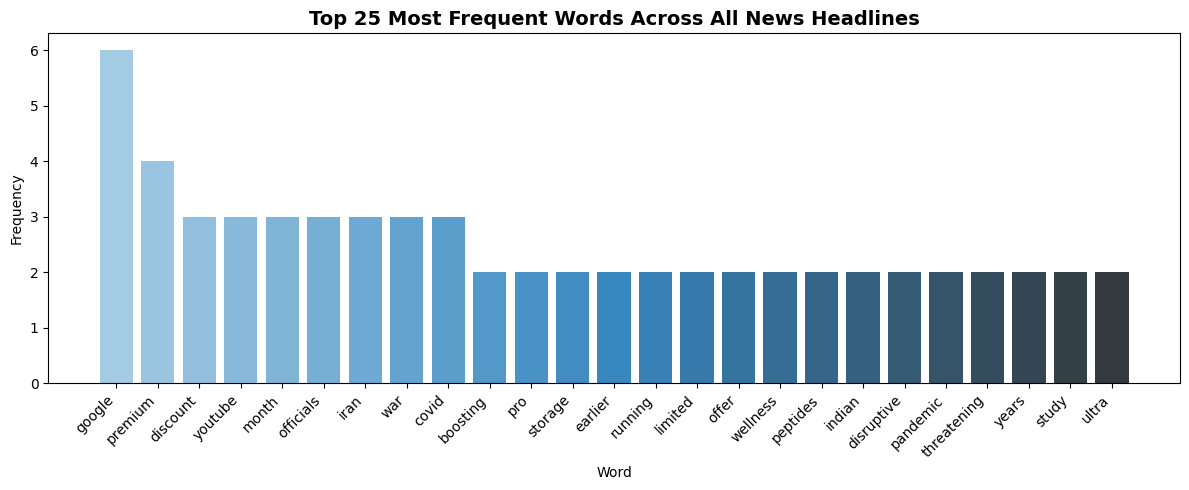

✅ Frequency chart displayed


In [35]:
# ── Visualize: Top 25 words bar chart ───────────────────────────
top_words = freq_dist.most_common(25)
print(top_words)

top_words = freq_dist.most_common(25)
words, counts = zip(*top_words)
print(words, counts)

plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=sns.color_palette("Blues_d", 25))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title("Top 25 Most Frequent Words Across All News Headlines", fontsize=14, fontweight='bold')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("✅ Frequency chart displayed")

In [36]:
text_for_cloud = " ".join(all_tokens)
print(text_for_cloud)

google discount takes youtube premium google boosting pro storage earlier month google running limited youtube premium discount offer boosting pro storage earlier month google running limited youtube premium discount offer available google premium subscribers paying per month amid wellness craze fda weighs lifting peptide restrictions washington post health secretary robert kennedy self professed big fan peptides grown popularity wellness antiaging many remain untested food drug administration taking step toward potentially allowing compounding pharmacies produce seven peptides currently restricted agencys previous indian officials see iran war oil shock disruptive covid india drawing covid era playbook cushion economic blow iran war officials warning disruption energy supplies rival pandemic threatening growth widening fiscal deficit pushing rupee record lows indian officials iran war disruptive economy covid pandemic six years ago damage linger years come threatening knock worlds fas

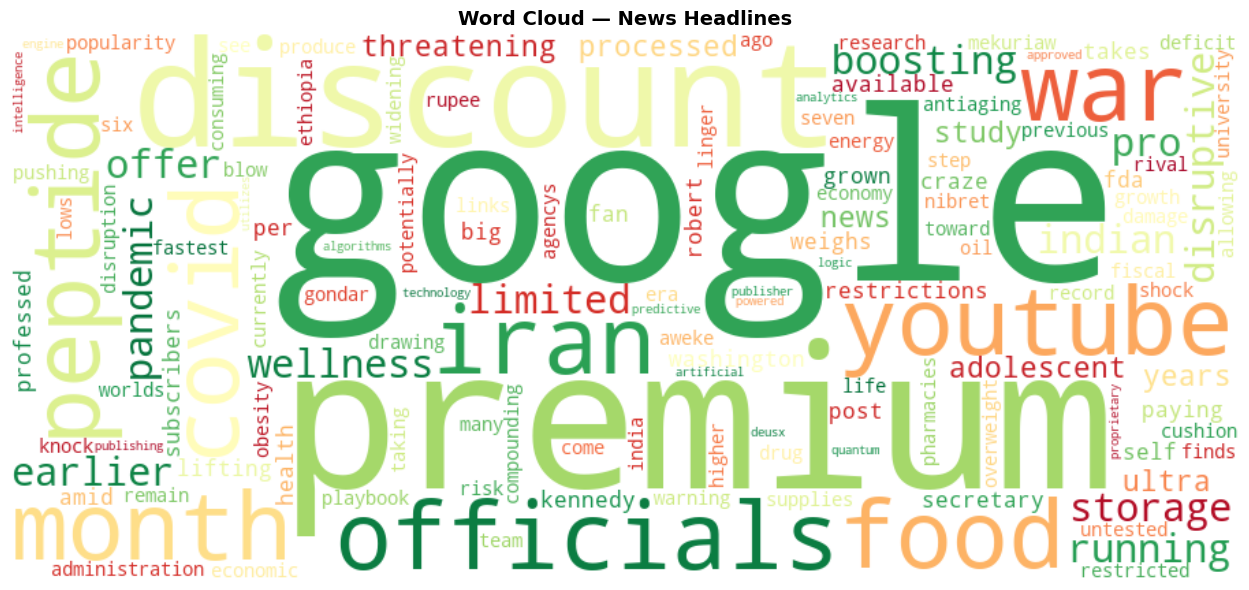

✅ Word cloud displayed


In [37]:
# ── Word Cloud ───────────────────────────────────────────────────

wc = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='RdYlGn',
    max_words=150,
    collocations=False
).generate(text_for_cloud)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — News Headlines", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Word cloud displayed")

In [38]:
tagged = nltk.pos_tag(df["tokens"][0])
print(tagged)

[('google', 'NN'), ('discount', 'NN'), ('takes', 'VBZ'), ('youtube', 'JJ'), ('premium', 'NN'), ('google', 'NN'), ('boosting', 'VBG'), ('pro', 'JJ'), ('storage', 'NN'), ('earlier', 'RBR'), ('month', 'NN'), ('google', 'NN'), ('running', 'VBG'), ('limited', 'JJ'), ('youtube', 'NN'), ('premium', 'NN'), ('discount', 'NN'), ('offer', 'NN'), ('boosting', 'VBG'), ('pro', 'JJ'), ('storage', 'NN'), ('earlier', 'RBR'), ('month', 'NN'), ('google', 'NN'), ('running', 'VBG'), ('limited', 'JJ'), ('youtube', 'NN'), ('premium', 'NN'), ('discount', 'NN'), ('offer', 'NN'), ('available', 'JJ'), ('google', 'NN'), ('premium', 'NN'), ('subscribers', 'NNS'), ('paying', 'VBG'), ('per', 'IN'), ('month', 'NN')]


In [39]:
# ──Part-of-Speech (POS) tagging  — identify noun-heavy vs action-heavy headlines ──
def pos_tag_summary(tokens: list) -> dict:
    """Return counts of nouns, verbs, adjectives in a token list."""
    tagged = nltk.pos_tag(tokens)
    pos_counts = {"NN": 0, "VB": 0, "JJ": 0}  # nouns, verbs, adjectives
    for _, tag in tagged:
        if tag.startswith("NN"): pos_counts["NN"] += 1
        elif tag.startswith("VB"): pos_counts["VB"] += 1
        elif tag.startswith("JJ"): pos_counts["JJ"] += 1
    return pos_counts

# Apply to a sample (POS tagging is slow on large datasets)
sample_df = df.head(50).copy()
sample_df["pos_tags"] = sample_df["tokens"].apply(pos_tag_summary)
sample_df["noun_count"] = sample_df["pos_tags"].apply(lambda x: x["NN"])
sample_df["verb_count"] = sample_df["pos_tags"].apply(lambda x: x["VB"])
sample_df["adj_count"]  = sample_df["pos_tags"].apply(lambda x: x["JJ"])

print("POS distribution (sample of 50 headlines):")
print(f"  Avg nouns per headline:      {sample_df['noun_count'].mean():.1f}")
print(f"  Avg verbs per headline:      {sample_df['verb_count'].mean():.1f}")
print(f"  Avg adjectives per headline: {sample_df['adj_count'].mean():.1f}")

print(sample_df.head())

POS distribution (sample of 50 headlines):
  Avg nouns per headline:      24.2
  Avg verbs per headline:      9.0
  Avg adjectives per headline: 8.5
                                               title  \
0  Google One discount takes 50% off YouTube Prem...   
1  Amid wellness craze, FDA weighs lifting peptid...   
2  Indian officials see Iran war oil shock as dis...   
3  Study Links Ultra-Processed Foods to Adolescen...   

                                         description               source  \
0  After boosting AI Pro storage earlier this mon...       9to5google.com   
1  Health Secretary Robert F. Kennedy Jr. is a se...  The Washington Post   
2  India is drawing on its Covid-era playbook to ...   The Times of India   
3  Study finds higher overweight risk in adolesce...   Lifetechnology.com   

                                                 url  \
0  http://9to5google.com/2026/04/15/google-one-yo...   
1  https://www.washingtonpost.com/health/2026/04/...   
2  https://econo

---
## Section 4B - Stemming and Lemmatization

### Concept
Different forms of the same word should count as one word.



| Approach       | How                         | "running"  | "studies"       |
|----------------|-----------------------------|-----------|-----------------|
| Stemming       | Chops endings (crude, fast) | run       | studi (WRONG)   |
| Lemmatization  | Uses dictionary (accurate)  | run       | study (RIGHT)   |

**Rule: Always use Lemmatization for NLP. Stemming only when speed matters more than accuracy.**

In [41]:
# ── Stemming vs Lemmatization ───────────────────────────────────
# Run this cell and observe the differences
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet', quiet=True)

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

words = ["running", "studies", "better", "wolves", "caring", "happily", "economics"]

print(f"{'Word':<15} | {'Stem':<15} | Lemma")
print("-" * 45)
for word in words:
    stem  = stemmer.stem(word)
    lemma = lemmatizer.lemmatize(word, pos='v')   # pos='v' = treat as verb
    print(f"{word:<15} | {stem:<15} | {lemma}")

# Apply lemmatization to all article tokens
df["tokens_lemmatized"] = df["tokens"].apply(
    lambda token_list: [lemmatizer.lemmatize(t, pos='v') for t in token_list]
)
print(f"Example before: {df['tokens'][0][:5]}")
print(f"Example after:  {df['tokens_lemmatized'][0][:5]}")

Word            | Stem            | Lemma
---------------------------------------------
running         | run             | run
studies         | studi           | study
better          | better          | better
wolves          | wolv            | wolves
caring          | care            | care
happily         | happili         | happily
economics       | econom          | economics
Example before: ['google', 'discount', 'takes', 'youtube', 'premium']
Example after:  ['google', 'discount', 'take', 'youtube', 'premium']


---
## Section 4C - N-grams (Phrases, Not Just Words)

### Concept
An n-gram is a sequence of N consecutive words. Captures phrases instead of just single words.



**Why Important:**
- "not good" as a bigram = negative. As unigrams "not" + "good" loses the meaning.
- "interest rate" means something specific. Separate words mean less.
- N-grams reveal common phrases in news data (e.g. "interest rate", "stock market").

In [42]:
# ── N-grams: extract common phrases from headlines ──────────────
from nltk.util import ngrams
from nltk.probability import FreqDist

# Example: bigrams from a single headline
sample_tokens = df["tokens"][0]
bigrams_sample = list(ngrams(sample_tokens, 2))
print(f"Sample headline tokens: {sample_tokens}")
print(f"Bigrams from this headline:")
for bg in bigrams_sample[:8]:
    print(f"  {bg}")

# Extract bigrams across ALL articles
all_bigrams = []
for token_list in df["tokens"]:
    all_bigrams.extend(ngrams(token_list, 2))

bigram_freq = FreqDist([" ".join(bg) for bg in all_bigrams])

print(f"Total bigrams found: {len(all_bigrams):,}")
print(f"Top 15 most common 2-word phrases in news headlines:")
for phrase, count in bigram_freq.most_common(15):
    print(f"  {phrase:<30} {count}")

Sample headline tokens: ['google', 'discount', 'takes', 'youtube', 'premium', 'google', 'boosting', 'pro', 'storage', 'earlier', 'month', 'google', 'running', 'limited', 'youtube', 'premium', 'discount', 'offer', 'boosting', 'pro', 'storage', 'earlier', 'month', 'google', 'running', 'limited', 'youtube', 'premium', 'discount', 'offer', 'available', 'google', 'premium', 'subscribers', 'paying', 'per', 'month']
Bigrams from this headline:
  ('google', 'discount')
  ('discount', 'takes')
  ('takes', 'youtube')
  ('youtube', 'premium')
  ('premium', 'google')
  ('google', 'boosting')
  ('boosting', 'pro')
  ('pro', 'storage')
Total bigrams found: 175
Top 15 most common 2-word phrases in news headlines:
  youtube premium                3
  iran war                       3
  boosting pro                   2
  pro storage                    2
  storage earlier                2
  earlier month                  2
  month google                   2
  google running                 2
  running li

---
## Section 4D - TF-IDF (Term Frequency - Inverse Document Frequency)

### Concept
Problem with plain frequency: "market" appears 100 times but if it is in EVERY article it is not distinctive.

TF-IDF scores words by how important they are to ONE article compared to ALL articles.



| Word             | This article | All articles | TF-IDF | Verdict             |
|------------------|--------------|--------------|--------|---------------------|
| "market"         | 10x          | every        | low    | common, not useful  |
| "cryptocurrency" | 8x           | 2 articles   | high   | distinctive!        |
| "the"            | 20x          | every        | ~0     | useless             |

TF-IDF helps find the most distinctive/important words for EACH article.

In [ ]:
# ── TF-IDF: find most distinctive words per article ────────────
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Join tokens back into strings for TF-IDF
texts_for_tfidf = df["tokens"].apply(lambda t: " ".join(t))

vectorizer   = TfidfVectorizer(max_features=50)  # top 50 words
tfidf_matrix = vectorizer.fit_transform(texts_for_tfidf)
feature_names = vectorizer.get_feature_names_out()

# Show top TF-IDF words for the first 3 articles
print("Top distinctive words per article (TF-IDF):")
print("-" * 60)
for i in range(min(3, len(df))):
    scores    = tfidf_matrix[i].toarray()[0]
    top_idx   = scores.argsort()[::-1][:5]          # top 5 indices
    top_words = [(feature_names[j], round(scores[j], 3)) for j in top_idx if scores[j] > 0]
    print(f"
Article {i+1}: {df['title'].iloc[i][:60]}")
    print(f"  Distinctive words: {top_words}")

print("
Note: compare these to the plain frequency top words above")
print("TF-IDF picks words unique to EACH article, not just common ones")

---
## 💬 Section 5 — Sentiment Analysis with Classical NLP

### Concept: Sentiment Analysis
We use **two complementary approaches**:

| Tool | Approach | Best For |
|---|---|---|
| **VADER** | Rule-based lexicon + social-media rules | Short texts, headlines, informal writing |
| **TextBlob** | Pattern-based with polarity/subjectivity | Slightly longer, more formal text |

**VADER scores:**
- `compound` — overall score from -1 (most negative) to +1 (most positive)
- `pos / neu / neg` — proportion of positive, neutral, negative words

**TextBlob scores:**
- `polarity` — -1 to +1 (negative to positive)
- `subjectivity` — 0 to 1 (objective to subjective)

VADER:    {'neg': 0.18, 'neu': 0.6, 'pos': 0.22, 'compound': 0.042}
TextBlob: polarity=0.05, subjectivity=0.52
```

---

## VADER scores

**`compound`** — the single summary score for the whole sentence, from -1.0 to +1.0.

It is calculated by combining all word scores, adjusting for grammar rules (negations, caps, punctuation), then normalising to fit between -1 and +1. This is the one number you use to label a sentence as Positive, Negative, or Neutral.
```
"The economy is growing steadily but unemployment remains a serious concern"
compound = +0.042  → Neutral  (just above zero — mixed message, slightly positive)

"Markets crash in worst single day since 2008"
compound = -0.74   → Negative

"Scientists announce a brilliant breakthrough cure"
compound = +0.81   → Positive
```

Rule of thumb: `>= +0.05` = Positive, `<= -0.05` = Negative, in between = Neutral.

---

**`pos`** — proportion of words in the sentence that carry positive meaning, from 0.0 to 1.0.

Not a sentiment score — a word *ratio*. It tells you how many of the total words were flagged as positive by the lexicon.
```
"The economy is growing steadily but unemployment remains a serious concern"
pos = 0.22  → 22% of words carry positive signal ("growing", "steadily")
```
```
"Absolutely wonderful, brilliant, fantastic news today"
pos = 0.75  → 75% of words are positive
```

---

**`neu`** — proportion of words that are emotionally neutral — carrying no positive or negative signal.

Most grammatical words (the, is, but, remains) and factual nouns (economy, unemployment) score as neutral. In news headlines this is usually the largest of the three scores.
```
"The economy is growing steadily but unemployment remains a serious concern"
neu = 0.60  → 60% of words are neutral ("the", "is", "but", "remains", "unemployment")
```
```
"Cat sits on mat"
neu = 1.0   → 100% neutral, zero emotional content
```

---

**`neg`** — proportion of words that carry negative meaning, from 0.0 to 1.0.

The mirror of `pos`. Note that `pos + neu + neg` always adds up to exactly 1.0 — they are shares of the same whole.
```
"The economy is growing steadily but unemployment remains a serious concern"
neg = 0.18  → 18% of words carry negative signal ("concern", "serious")

pos(0.22) + neu(0.60) + neg(0.18) = 1.0  ✓
```
```
"Devastating floods destroy entire village leaving families homeless"
neg = 0.71  → 71% of words are negative
```

---

## TextBlob scores

**`polarity`** — overall positive/negative direction of the sentence, from -1.0 to +1.0.

Conceptually similar to VADER's `compound` but calculated differently — TextBlob looks primarily at adjectives and adverbs and averages their dictionary scores. It does not apply the grammar adjustment rules that VADER does.
```
"The economy is growing steadily but unemployment remains a serious concern"
polarity = +0.05  → nearly neutral, slight positive lean
                    ("growing" and "steadily" are mildly positive,
                     "serious" and "concern" pull it back down)
```
```
"Terrible, catastrophic losses devastate investors"
polarity = -0.85  → strongly negative (adjectives dominate)

"A truly magnificent and inspiring discovery"
polarity = +0.90  → strongly positive (stacked positive adjectives)
```

---

**`subjectivity`** — how much the sentence is opinion vs fact, from 0.0 (fully objective) to 1.0 (fully subjective).

This score has no equivalent in VADER. It is TextBlob's unique contribution to this project. A sentence full of adjectives and personal judgement words scores high. A sentence of facts and numbers scores low.
```
"The economy is growing steadily but unemployment remains a serious concern"
subjectivity = 0.52  → moderate — "serious concern" is opinion,
                        "growing steadily" is borderline fact/opinion
```
```
"GDP grew by 2.4% in Q3 according to official figures"
subjectivity = 0.05  → nearly pure fact, no opinion words at all

"This is absolutely the worst government policy in living memory"
subjectivity = 0.95  → almost entirely opinion

In [ ]:
# ── Initialise VADER ─────────────────────────────────────────────
vader = SentimentIntensityAnalyzer()


def vader_sentiment(text: str) -> dict:
    """Run VADER on raw (uncleaned) text — VADER works best on original text."""
    scores = vader.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = "Positive"
    elif compound <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"
    return {"vader_compound": compound,
            "vader_pos": scores['pos'],
            "vader_neu": scores['neu'],
            "vader_neg": scores['neg'],
            "vader_label": label}


In [ ]:
def textblob_sentiment(text: str) -> dict:
    """Run TextBlob on text."""
    blob = TextBlob(text)
    pol  = blob.sentiment.polarity
    subj = blob.sentiment.subjectivity
    if pol > 0.05:     label = "Positive"
    elif pol < -0.05:  label = "Negative"
    else:              label = "Neutral"
    return {"tb_polarity": pol, "tb_subjectivity": subj, "tb_label": label}

In [ ]:
# ── Apply to every headline (use title + description for best results) ─
print("Running sentiment analysis...")
vader_results  = df["clean_text"].apply(vader_sentiment).apply(pd.Series)
textblob_results = df["clean_text"].apply(textblob_sentiment).apply(pd.Series)


print(vader_results)
print(textblob_results)

In [ ]:
df = pd.concat([df, vader_results, textblob_results], axis=1)

In [ ]:
df.head()

In [ ]:
# ── Consensus sentiment label ────────────────────────────────────────────────
# Two models (VADER + TextBlob) each produce a label: Positive / Neutral / Negative.
# Decision rules:
#   Both agree             → use that label (high confidence)
#   One Neutral, one other → trust the non-neutral one (stronger signal wins)
#   Both non-neutral but differ (Pos vs Neg) → call it Neutral (conflicted signal)
def consensus_label(row):
    if row["vader_label"] == row["tb_label"]:
        return row["vader_label"]                  # both models agree
    if row["vader_label"] == "Neutral":
        return row["tb_label"]                     # VADER is unsure → trust TextBlob
    if row["tb_label"] == "Neutral":
        return row["vader_label"]                  # TextBlob unsure → trust VADER
    return "Neutral"                               # conflicting → call it Neutral

df["consensus_label"] = df.apply(consensus_label, axis=1)

print(f"\nSentiment analysis complete on {len(df)} articles")
print("\nConsensus label distribution:")
print(df["consensus_label"].value_counts())


In [ ]:
# ── Show example headlines with their sentiment scores ───────────
cols = ["title", "category", "vader_compound", "tb_polarity", "tb_subjectivity", "consensus_label"]
display_df = df[cols].sort_values("vader_compound", ascending=False)

print("🟢 Top 5 Most POSITIVE headlines:")
for _, row in display_df.head(5).iterrows():
    print(f"  [{row['consensus_label']:8s} | score: {row['vader_compound']:+.2f}] {row['title'][:80]}")

print("\n🔴 Top 5 Most NEGATIVE headlines:")
for _, row in display_df.tail(5).iterrows():
    print(f"  [{row['consensus_label']:8s} | score: {row['vader_compound']:+.2f}] {row['title'][:80]}")

In [ ]:
# ── Visualize 1: Sentiment distribution by category ──────────────
COLOR_MAP = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}

cat_sentiment = df.groupby(["category", "consensus_label"]).size().unstack(fill_value=0)
print(cat_sentiment
      )
cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100

In [ ]:


ax = cat_sentiment_pct.plot(
    kind='bar', stacked=True, figsize=(12, 5),
    color=[COLOR_MAP.get(c, '#cccccc') for c in cat_sentiment_pct.columns]
)
plt.title("Sentiment Distribution by News Category (%)", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Percentage of Articles")
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print("✅ Stacked bar chart displayed")

---
## 🕷️ Section 6 — Web Scraping with BeautifulSoup & Requests

### Concept: Web Scraping
NewsAPI only returns truncated article content. We can fetch the **full article text**  
by scraping the source page directly.

**Pipeline:**
1. `requests.get(url)` — download the HTML page
2. `BeautifulSoup(html, 'html.parser')` — parse the HTML tree
3. `.find_all('p')` — extract paragraph tags
4. Join and clean the text

**Responsible scraping rules:**
- Add `time.sleep()` between requests
- Set a User-Agent header (polite identification)
- Respect `robots.txt` (not covered here but important in production)

In [ ]:
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

In [ ]:
def scrape_article_text(url: str, timeout: int = 8) -> str:
    """
    Scrape full article text from a given URL.
    Returns cleaned paragraph text or empty string on failure.
    """
    try:
        response = requests.get(url, headers=HEADERS, timeout=timeout)
        response.raise_for_status()                        # raise on 4xx/5xx

        soup = BeautifulSoup(response.text, 'html.parser')
        print('soup',soup)
        # ── Strategy 1: look for <article> tag (modern sites) ────
        article_tag = soup.find('article')
        print(article_tag, 'article_tag')
        if article_tag:
            paragraphs = article_tag.find_all('p')
        else:
            # ── Strategy 2: fall back to all <p> tags ────────────
            paragraphs = soup.find_all('p')
        print('paragraph', paragraphs)
        # Extract and join non-empty paragraph text
        text = ' '.join(
            p.get_text(strip=True)
            for p in paragraphs
            if len(p.get_text(strip=True)) > 40   # skip tiny/nav paragraphs
        )
        return text[:3000]   # cap at 3000 chars to keep things fast

    except Exception as e:
        return ""   # silently skip failed URLs
    
scrape_article_text('https://www.indiatoday.in/world/story/iran-lost-track-of-mines-it-planted-in-strait-of-hormuz-us-middle-east-war-2894654-2026-04-11')

In [ ]:
# ── Scrape full article text for a sample ────────────────────────────────────
# Only scraping 5 articles to keep the lab fast (full scrape = several minutes).
# scrape_article_text() fetches the live HTML page and extracts paragraph text.
# time.sleep(1) is a polite delay — avoids flooding the server with rapid requests.
SCRAPE_SAMPLE = 5
scrape_sample = df[df["url"].str.startswith("http")].head(SCRAPE_SAMPLE).copy()

print(f"Scraping {SCRAPE_SAMPLE} full articles...")
scraped_texts = []
for i, (idx, row) in enumerate(scrape_sample.iterrows()):
    text       = scrape_article_text(row["url"])
    word_count = len(text.split()) if text else 0
    scraped_texts.append(text)
    status = "OK  " if text else "FAIL"
    print(f"  [{status}] [{i+1}/{SCRAPE_SAMPLE}] {row['source']:20s} -> {word_count:4d} words")
    time.sleep(1)   # 1-second pause — be polite to the server

scrape_sample["scraped_text"] = scraped_texts
print("\nScraping complete.")
print(scrape_sample[["source", "title", "scraped_text"]].head())


In [ ]:
# ── Inspect what was scraped ─────────────────────────────────────
for _, row in scrape_sample.iterrows():
    if row["scraped_text"]:
        print(f"\n{'='*60}")
        print(f"SOURCE  : {row['source']}")
        print(f"HEADLINE: {row['title'][:80]}")
        print(f"SCRAPED TEXT PREVIEW (first 300 chars):")
        print(f"  {row['scraped_text'][:300]}...")
        break   # show just one example

In [ ]:
# ── Analyse scraped text with BeautifulSoup metadata extraction ──
def extract_page_metadata(url: str) -> dict:
    """
    Extract metadata (og:title, og:description, keywords) from a page.
    Demonstrates BeautifulSoup meta tag parsing.
    """
    try:
        response = requests.get(url, headers=HEADERS, timeout=8)
        soup = BeautifulSoup(response.text, 'html.parser')

        def get_meta(prop):
            tag = soup.find('meta', property=prop) or soup.find('meta', attrs={'name': prop})
            return tag['content'] if tag and tag.get('content') else None

        return {
            "og_title":       get_meta('og:title'),
            "og_description": get_meta('og:description'),
            "meta_keywords":  get_meta('keywords'),
            "h1_tags":        [h.get_text(strip=True) for h in soup.find_all('h1')][:3]
        }
    except Exception:
        return {}


# Demo on first article
sample_url = df[df["url"].str.startswith("http")]["url"].iloc[0]
meta = extract_page_metadata(sample_url)
print("Page metadata extracted via BeautifulSoup:")
for key, val in meta.items():
    print(f"  {key:20s}: {str(val)[:80]}")

---
## 📊 Section 7 — Full Dashboard: Collecting & Analyzing Web Data for NLP

This section brings everything together into a **multi-panel sentiment dashboard**  
that answers questions like:
- Which news category is most negative today?
- Which sources publish the most biased (subjective) headlines?
- What named entities appear most in negative news?
- How do sentiment scores distribute across the dataset?

In [ ]:
# ── Dashboard Panel 1: Sentiment Overview Pie ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"News Sentiment Dashboard  |  {datetime.now().strftime('%Y-%m-%d %H:%M')}",
             fontsize=15, fontweight='bold')

# Panel 1 — Overall pie
counts = df["consensus_label"].value_counts()
axes[0].pie(
    counts.values,
    labels=counts.index,
    colors=[COLOR_MAP[l] for l in counts.index],
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11}
)
axes[0].set_title("Overall Sentiment Split", fontweight='bold')

# Panel 2 — VADER compound distribution histogram
axes[1].hist(df["vader_compound"], bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title("VADER Compound Score Distribution", fontweight='bold')
axes[1].set_xlabel("Compound Score")
axes[1].set_ylabel("Count")

# Panel 3 — Average sentiment per category
cat_avg = df.groupby('category')['vader_compound'].mean().sort_values()
colors  = ['#e74c3c' if v < 0 else '#2ecc71' for v in cat_avg.values]
axes[2].barh(cat_avg.index, cat_avg.values, color=colors)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title("Avg VADER Score by Category", fontweight='bold')
axes[2].set_xlabel("Mean Compound Score")

plt.tight_layout()
plt.show()
print("✅ Dashboard Panel 1 displayed")

In [ ]:
# ── Dashboard Panel 3: Named entity frequency in negative news ───
negative_articles = df[df["consensus_label"] == "Negative"]
neg_entities = [e for entities in negative_articles["proper_nouns"] for e in entities]

if neg_entities:
    neg_freq = pd.Series(neg_entities).value_counts().head(20)

    plt.figure(figsize=(10, 5))
    neg_freq.plot(kind='barh', color='#e74c3c')
    plt.title("Top Named Entities in NEGATIVE Headlines (regex-extracted)",
              fontsize=13, fontweight='bold')
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print("✅ Named entity chart displayed")
else:
    print("No named entities found in negative articles (check your data).")

---
## 📋 Section 8 — Summary Report

Export findings to a clean tabular summary.

In [ ]:
# ── Print final summary ──────────────────────────────────────────
print("="*60)
print(" NEWS SENTIMENT DASHBOARD — SUMMARY REPORT")
print(f" Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)
print(f" Total articles analysed : {len(df)}")
print(f" Categories covered      : {', '.join(df['category'].unique())}")
print(f" Unique sources          : {df['source'].nunique()}")
print()
print(" SENTIMENT BREAKDOWN:")
for label, count in df['consensus_label'].value_counts().items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 3)
    print(f"   {label:10s} {bar:30s} {count:4d} ({pct:.1f}%)")
print()
print(" MOST POSITIVE CATEGORIES:")
cat_avg = df.groupby('category')['vader_compound'].mean().sort_values(ascending=False)
for cat, score in cat_avg.items():
    emoji = '🟢' if score > 0.05 else ('🔴' if score < -0.05 else '⚪')
    print(f"   {emoji} {cat:20s} score: {score:+.3f}")
print()
print(" TOP KEYWORDS IN HEADLINES:")
for word, count in freq_dist.most_common(10):
    print(f"   {word:20s} {count} mentions")
print("="*60)

In [ ]:
# ── Export final DataFrame to CSV ────────────────────────────────
output_cols = [
    'title', 'source', 'category', 'published_at',
    'vader_compound', 'vader_label',
    'tb_polarity', 'tb_subjectivity', 'tb_label',
    'consensus_label', 'token_count', 'url'
]
df[output_cols].to_csv('news_sentiment_results.csv', index=False)
print("✅ Results saved to news_sentiment_results.csv")
print(f"   Shape: {df[output_cols].shape}")
df[output_cols].head()

---
## 🚀 Section 9 — Extensions & Challenges

Once you've completed the above, try these extensions:

### 🔵 Beginner
1. Change `CATEGORIES` to include different news categories
2. Change `COUNTRY` to `in` (India), `gb` (UK), etc. and compare sentiment
3. Add more stopwords to the `STOP_WORDS` set and see how the word cloud changes

### 🟡 Intermediate
4. Add a **time series plot**: group articles by `published_at` hour and plot sentiment over time
5. Build a **Source Bias Meter**: rank sources by their average subjectivity score
6. Compare VADER vs TextBlob agreement rate — when do they disagree?

### 🔴 Advanced
7. Replace VADER with a **HuggingFace transformer** (`distilbert-base-uncased-finetuned-sst-2-english`) — does it give better results?
8. Use **spaCy** for proper Named Entity Recognition instead of the regex heuristic
9. Schedule the notebook to run every hour and log sentiment trends to a SQLite database
10. Build a **Streamlit app** from this notebook for a live interactive dashboard

---

## 📖 References
- NewsAPI docs: https://newsapi.org/docs
- VADER paper: https://ojs.aaai.org/index.php/ICWSM/article/view/14550
- TextBlob docs: https://textblob.readthedocs.io
- BeautifulSoup docs: https://www.crummy.com/software/BeautifulSoup/bs4/doc/
- NLTK book (free): https://www.nltk.org/book/